## **Training pipeline**

In [7]:
import torch

# =========================
# CONFIG
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 5           # có thể config
BATCH_SIZE = 10           # có thể config
LEARNING_RATE = 0.005    # chuẩn cho Faster R-CNN
NUM_CLASSES = 80 + 1          # COCO 2017: 80 classes + 1 background
NUM_WORKERS = 8

In [3]:
import os
import torch
import torch.utils.data
from torchvision.datasets import CocoDetection
import torchvision.transforms as T

class CocoDataset(CocoDetection):
    def __init__(self, root, annFile, transforms=None):
        super(CocoDataset, self).__init__(root, annFile)
        self.transforms = transforms

    def __getitem__(self, index):
        img, target = super(CocoDataset, self).__getitem__(index)
        image_id = self.ids[index]

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        # Lấy danh sách ID gốc của COCO (để map về liên tục 1-80)
        coco_ids = self.coco.getCatIds()
        cat_id_map = {old_id: i + 1 for i, old_id in enumerate(coco_ids)}

        for obj in target:
            xmin, ymin, w, h = obj['bbox']
            # Đảm bảo box hợp lệ (xmax > xmin, ymax > ymin)
            if w > 0 and h > 0:
                boxes.append([xmin, ymin, xmin + w, ymin + h])
                labels.append(cat_id_map[obj['category_id']]) # Dùng ID đã map
                areas.append(obj['area'])
                iscrowd.append(obj['iscrowd'])

        # Xử lý trường hợp ảnh không có object (tránh lỗi crash)
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            area = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        image_id = torch.tensor([image_id])

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

# Hàm helper để xử lý batch (vì mỗi ảnh có số lượng object khác nhau)
def collate_fn(batch):
    return tuple(zip(*batch))

In [5]:
import torchvision.transforms.functional as F

class ToTensor:
    def __call__(self, image, target):
        # chỉ convert nếu image là PIL
        from PIL import Image
        import torch

        if isinstance(image, Image.Image):
            import torchvision.transforms.functional as F
            image = F.to_tensor(image)

        # else giữ nguyên nếu đã là Tensor
        return image, target


def get_transform():
    return ToTensor()

In [ ]:
# COCO_ROOT="/content/coco"
# !mkdir -p $COCO_ROOT

# # Download val2017 images
# !wget -nc http://images.cocodataset.org/zips/val2017.zip -P $COCO_ROOT
# !unzip -q $COCO_ROOT/val2017.zip -d $COCO_ROOT

# # Download annotations
# !wget -nc http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P $COCO_ROOT
# !unzip -q $COCO_ROOT/annotations_trainval2017.zip -d $COCO_ROOT

In [6]:
COCO_ROOT="/content/coco"
!mkdir -p $COCO_ROOT

# Download train2017 images
!wget -nc http://images.cocodataset.org/zips/train2017.zip -P $COCO_ROOT
!unzip -q $COCO_ROOT/train2017.zip -d $COCO_ROOT

# Download annotations (vẫn dùng chung cho train + val)
!wget -nc http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P $COCO_ROOT
!unzip -q $COCO_ROOT/annotations_trainval2017.zip -d $COCO_ROOT

--2026-04-06 02:05:57--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 54.231.160.105, 3.5.29.212, 16.182.38.249, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|54.231.160.105|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘/content/coco/train2017.zip’

train2017.zip       100%[===================>]  18.01G  37.2MB/s    in 5m 45s  

2026-04-06 02:11:42 (53.5 MB/s) - ‘/content/coco/train2017.zip’ saved [19336861798/19336861798]

--2026-04-06 02:13:37--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.252.253, 3.5.29.233, 16.15.191.28, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.252.253|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘/content/coco/

In [8]:
# ann_path = f"{COCO_ROOT}/annotations/instances_val2017.json"
# img_path = f"{COCO_ROOT}/val2017"

ann_path = f"{COCO_ROOT}/annotations/instances_train2017.json"
img_path = f"{COCO_ROOT}/train2017"

# Khởi tạo Dataset
dataset = CocoDataset(
    root=img_path,
    annFile=ann_path,
    transforms=get_transform()
)


## JUST FOR SAMPLING - START
# from torch.utils.data import Subset

# class SubsetWithAttr(Subset):
#     def __init__(self, dataset, indices):
#         super().__init__(dataset, indices)
#         # copy các thuộc tính gốc
#         self.coco = dataset.coco
#         self.cat2label = getattr(dataset, 'cat2label', None)

# dataset = SubsetWithAttr(dataset, list(range(100)))
## JUST FOR SAMPLING - END

print(f"Số lượng ảnh trong tập data: {len(dataset)}")

loading annotations into memory...
Done (t=7.48s)
creating index...
index created!
Số lượng ảnh trong tập data: 118287


In [9]:
from torch.utils.data import DataLoader, random_split

# 1. Tính toán kích thước các phần (70% train, 20% val, 10% test)
dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.2 * dataset_size)
test_size = dataset_size - train_size - val_size  # phần còn lại = 10%

# 2. Chia dataset ngẫu nhiên
train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# 3. DataLoader cho train
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

# 4. DataLoader cho val
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

# 5. DataLoader cho test
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

print(f"Tổng số ảnh: {dataset_size}")
print(f"Số ảnh training: {len(train_dataset)}")
print(f"Số ảnh validation: {len(val_dataset)}")
print(f"Số ảnh testing: {len(test_dataset)}")

# Thử lấy 1 batch train
images, targets = next(iter(train_loader))
print(f"Batch images shape: {len(images)}")

Tổng số ảnh: 118287
Số ảnh training: 82800
Số ảnh validation: 23657
Số ảnh testing: 11830
Batch images shape: 10


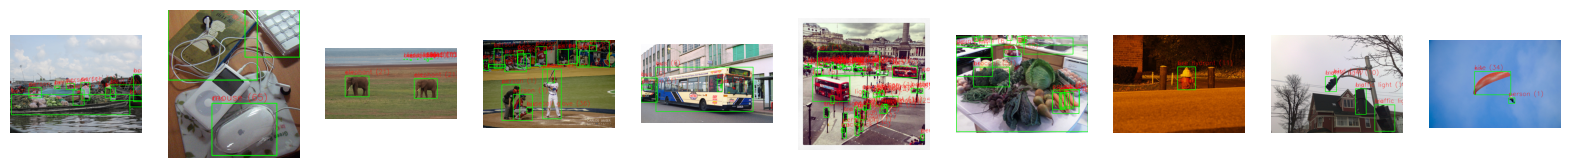

In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2  # OpenCV để vẽ box và text
from torchvision.utils import make_grid

# 1. Lấy danh sách COCO gốc
coco_cats = dataset.coco.cats
coco_ids = list(coco_cats.keys())  # [1,2,3,...,90 nhưng 80 class thực tế]

# 2. Map từ label 1-80 → tên
cat_id_to_name_mapped = {i+1: coco_cats[coco_ids[i]]['name'] for i in range(len(coco_ids))}

def show_batch(images, targets):
    fig, ax = plt.subplots(1, len(images), figsize=(20, 10))

    for i, (img, target) in enumerate(zip(images, targets)):
        # 1. Chuyển Tensor (C, H, W) -> Numpy (H, W, C)
        img_np = img.permute(1, 2, 0).cpu().numpy()

        # 3. Clip và chuyển sang uint8 (0-255) để OpenCV vẽ
        img_np = np.clip(img_np, 0, 1)
        img_np = (img_np * 255).astype(np.uint8)

        # 4. Chuyển RGB → BGR cho OpenCV (vẽ box)
        img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

        boxes = target['boxes'].cpu().numpy()
        labels = target['labels'].cpu().numpy()

        for box, label in zip(boxes, labels):
            xmin, ymin, xmax, ymax = box.astype(int)
            cv2.rectangle(img_bgr, (xmin, ymin), (xmax, ymax), (0,255,0), 2)  # Màu đỏ
            cv2.putText(img_bgr, f"ID:{label}", (xmin, max(ymin-10,0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

            #. Thêm tên class
            label_name = cat_id_to_name_mapped[label]  # label ở đây là 1..80
            cv2.putText(img_bgr, f"{label_name} ({label})",
                        (xmin, max(ymin-10,0)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        1.0,   # font scale lớn hơn
                        (0,0,255),
                        1,     # độ dày
                        cv2.LINE_AA)

        # 5. Chuyển lại BGR → RGB để matplotlib hiển thị đúng
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        ax[i].imshow(img_rgb)
        ax[i].axis('off')

    plt.show()

# --- Chạy thử ---
images, targets = next(iter(train_loader))
show_batch(images, targets)

In [11]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.5 MB/s eta 0:00:00


In [14]:
# =========================
# IMPORTS
# =========================
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# =========================
# MOUNT DRIVE (để lưu model)
# =========================
from google.colab import drive
drive.mount('/content/drive')
SAVE_PATH = "/content/drive/MyDrive/train/best_model.pth"
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

# =========================
# 1. KHỞI TẠO MODEL
# =========================
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

# Replace classifier head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(DEVICE)

# =========================
# LOAD CHECKPOINT NẾU TỒN TẠI
# =========================
if os.path.exists(SAVE_PATH):
    checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint)
    print(f"✅ Loaded pretrained model from {SAVE_PATH}")
else:
    print("⚠️ No pretrained model found, training from scratch.")

# =========================
# 2. OPTIMIZER & SCHEDULER
# =========================
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# =========================
# 3. TRAIN LOOP + VALIDATION + SAVE BEST MODEL
# =========================
best_map = 0.0  # track best mAP

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for images, targets in pbar:
        images = list(img.to(DEVICE) for img in images)
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()
        pbar.set_postfix({"loss": running_loss / (pbar.n + 1)})

    # Update learning rate
    lr_scheduler.step()

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Train Loss: {running_loss / len(train_loader):.4f}")

    # =========================
    # VALIDATION STEP
    # =========================
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")
    with torch.no_grad():
        for images, targets in val_loader:
            images = list(img.to(DEVICE) for img in images)
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            outputs = model(images)
            metric.update(outputs, targets)
    val_map = metric.compute()['map'].item()  # mAP@0.5:0.95
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Val mAP: {val_map:.4f}")

    # Lưu weights nếu performance tốt hơn
    if val_map > best_map:
        best_map = val_map
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"✅ New best model saved with mAP: {best_map:.4f} at {SAVE_PATH}")

print("✅ Training done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚠️ No pretrained model found, training from scratch.


Epoch 1/5: 100%|██████████| 8280/8280 [32:40<00:00,  4.22it/s, loss=0.573]

Epoch [1/5] - Train Loss: 0.5729


Epoch [1/5] - Val mAP: 0.3511
✅ New best model saved with mAP: 0.3511 at /content/drive/MyDrive/train/best_model.pth


Epoch 2/5: 100%|██████████| 8280/8280 [32:53<00:00,  4.20it/s, loss=0.55]

...

Epoch [4/5] - Train Loss: 0.4859


Epoch [4/5] - Val mAP: 0.3734
✅ New best model saved with mAP: 0.3734 at /content/drive/MyDrive/train/best_model.pth


Epoch 5/5: 100%|██████████| 8280/8280 [32:56<00:00,  4.19it/s, loss=0.472]

Epoch [5/5] - Train Loss: 0.4720


Epoch [5/5] - Val mAP: 0.3733
✅ Training done!


In [20]:
import time
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# =========================
# TEST STEP
# =========================
model.eval()  # chuyển sang chế độ eval
metric = MeanAveragePrecision(iou_type="bbox")
total_images = 0  # để tính FPS

start_time = time.time()
with torch.no_grad():
    for images, targets in test_loader:
        batch_size = len(images)
        total_images += batch_size

        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        outputs = model(images)
        metric.update(outputs, targets)
end_time = time.time()

# =========================
# Tính mAP
# =========================
test_map_results = metric.compute()

# In mAP tổng (0.5:0.95)
test_map = test_map_results['map'].item()
print(f"✅ Test mAP (0.5:0.95) = {test_map:.4f}")

# =========================
# Tính FPS
# =========================
elapsed_time = end_time - start_time
fps = total_images / elapsed_time
print(f"\n⏱ FPS: {fps:.2f} images/sec")

# In thêm các metrics khác, dùng float để tránh lỗi với tensor int
print("\nAdditional metrics:")
for k, v in test_map_results.items():
    if isinstance(v, torch.Tensor):
        if v.numel() == 1:
            print(f"{k}: {v.item():.4f}")
        else:
            print(f"{k} mean over classes: {v.float().mean().item():.4f}")
            # nếu muốn in từng class (tùy chọn)
            # for i, val in enumerate(v):
            #     print(f"{k} class {i+1}: {val:.4f}")

✅ Test mAP (0.5:0.95) = 0.3765

⏱ FPS: 83.66 images/sec

Additional metrics:
map: 0.3765
map_50: 0.6030
map_75: 0.4053
map_small: 0.2232
map_medium: 0.4128
map_large: 0.4556
mar_1: 0.3108
mar_10: 0.5042
mar_100: 0.5317
mar_small: 0.3415
mar_medium: 0.5740
mar_large: 0.6614
map_per_class: -1.0000
mar_100_per_class: -1.0000
classes mean over classes: 40.5000


In [18]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image
import numpy as np
import gradio as gr
import torchvision.transforms as T

# =========================
# CẤU HÌNH
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# LOAD MODEL
# =========================
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# =========================
# TRANSFORM ẢNH
# =========================
def transform_image(image):
    transform = T.Compose([
        T.ToTensor()
    ])
    return transform(image).to(DEVICE)

# =========================
# PREDICT FUNCTION
# =========================
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter',
    'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog',
    'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table',
    'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

def predict(image):
    image_tensor = transform_image(image).unsqueeze(0)  # batch=1
    with torch.no_grad():
        outputs = model(image_tensor)[0]

    # Lọc theo threshold
    threshold = 0.5
    boxes = outputs['boxes'][outputs['scores'] > threshold].cpu().numpy()
    labels = outputs['labels'][outputs['scores'] > threshold].cpu().numpy()
    scores = outputs['scores'][outputs['scores'] > threshold].cpu().numpy()

    # Vẽ lên ảnh
    img = np.array(image)
    import cv2
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), color=(0,255,0), thickness=2)
        cv2.putText(img, f"{COCO_CLASSES[label]}:{score:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
    return img

# =========================
# GRADIO UI
# =========================
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Image(type="numpy"),
    title="Faster R-CNN COCO Predictor",
    description="Upload an image to detect objects using your trained Faster R-CNN model."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://86b3b4322fbf86282d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
